In [154]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

## Load Data From CSV File

In [155]:
df = pd.read_csv("Heart.csv")
print(df.head(5))
print("\n", df['output'].value_counts())

   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  

 output
1    165
0    138
Name: count, dtype: int64


In [156]:
df.head()
print(df.shape)

(303, 14)


# Preprocessing

In [157]:

# Load data
df = pd.read_csv("Heart.csv")

# Replace missing-value markers
df = df.replace("?", np.nan)

# Convert columns to numeric
cols = [
    'age', 'sex', 'cp', 'trtbps', 'chol', 'fbs',
    'restecg', 'thalachh', 'exng', 'oldpeak',
    'slp', 'caa', 'thall', 'output'
]

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=cols)

# Remove duplicated rows
# df = df.drop_duplicates()

# Fill missing values
numeric_cols = [
    'age', 'trtbps', 'chol',
    'thalachh', 'oldpeak', 'caa', 'thall'
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Remove clearly invalid values
df = df[df['age'] > 0]
df = df[(df['trtbps'] > 0) & (df['trtbps'] <=250)]
df = df[df['chol'] > 0]
df = df[df['thalachh'] > 0]
df = df[df['oldpeak'] >= 0]

# Reset index
df = df.reset_index(drop=True)

# Check result
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nTarget distribution:")
print(df['output'].value_counts())

Shape: (303, 14)

Missing values:
age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

Data types:
age           int64
sex           int64
cp            int64
trtbps        int64
chol          int64
fbs           int64
restecg       int64
thalachh      int64
exng          int64
oldpeak     float64
slp           int64
caa           int64
thall         int64
output        int64
dtype: object

Target distribution:
output
1    165
0    138
Name: count, dtype: int64


In [158]:
print(df.shape)
print(X.shape)
print(y.shape)
print(df.head())

(303, 14)
(303, 13)
(303,)
   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  


In [159]:
X = np.asarray(df[['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg',   'thalachh', 'exng','oldpeak','slp','caa','thall']])
y = np.asarray(df['output'])

# Train & Test Split

In [160]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Logistic Regression


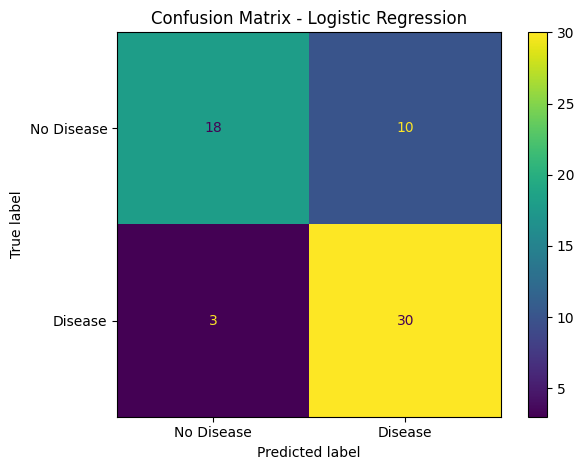

Best parameters : {'C': 0.1}
CV accuracy     : 0.8391156462585034
Train accuracy  : 0.8429752066115702
Test accuracy   : 0.7868852459016393
Precision       : 0.75
Recall          : 0.9090909090909091
Specificity     : 0.6428571428571429
F1-score        : 0.821917808219178
ROC-AUC         : 0.8787878787878788
Overfit gap     : 0.056089960709930886

Confusion Matrix:
[[18 10]
 [ 3 30]]
TN = 18
FP = 10
FN = 3
TP = 30

Linear SVM


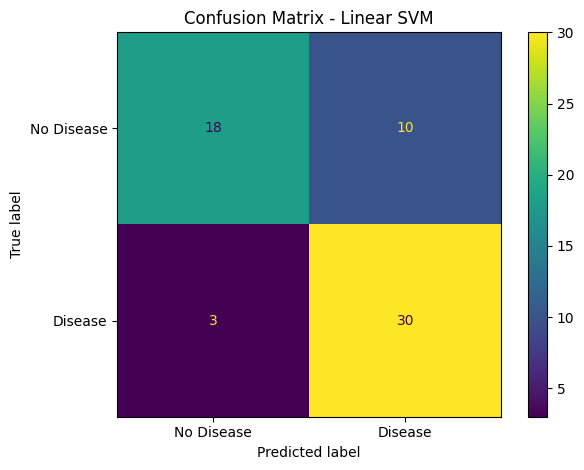

Best parameters : {'C': 1}
CV accuracy     : 0.8392857142857142
Train accuracy  : 0.859504132231405
Test accuracy   : 0.7868852459016393
Precision       : 0.75
Recall          : 0.9090909090909091
Specificity     : 0.6428571428571429
F1-score        : 0.821917808219178
ROC-AUC         : 0.8841991341991342
Overfit gap     : 0.07261888632976565

Confusion Matrix:
[[18 10]
 [ 3 30]]
TN = 18
FP = 10
FN = 3
TP = 30

Polynomial SVM


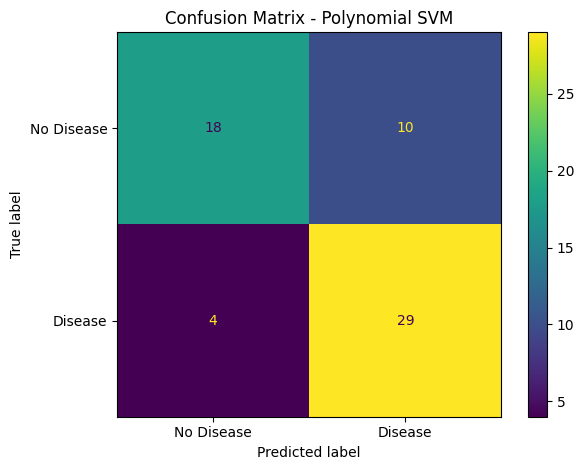

Best parameters : {'C': 1, 'degree': 3, 'gamma': 0.1}
CV accuracy     : 0.8266156462585034
Train accuracy  : 0.9462809917355371
Test accuracy   : 0.7704918032786885
Precision       : 0.7435897435897436
Recall          : 0.8787878787878788
Specificity     : 0.6428571428571429
F1-score        : 0.8055555555555556
ROC-AUC         : 0.9036796536796536
Overfit gap     : 0.17578918845684866

Confusion Matrix:
[[18 10]
 [ 4 29]]
TN = 18
FP = 10
FN = 4
TP = 29

RBF SVM


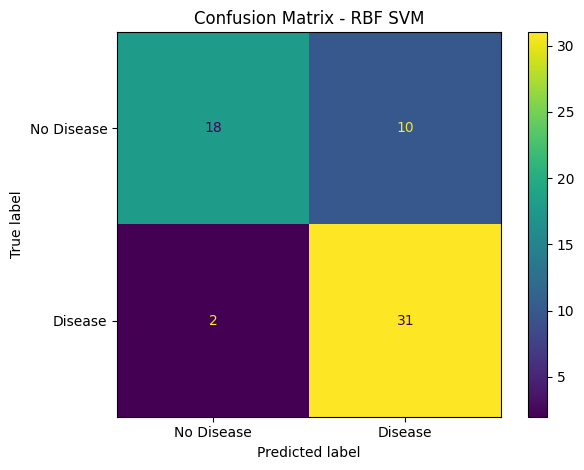

Best parameters : {'C': 100, 'gamma': 0.001}
CV accuracy     : 0.8597789115646257
Train accuracy  : 0.8677685950413223
Test accuracy   : 0.8032786885245902
Precision       : 0.7560975609756098
Recall          : 0.9393939393939394
Specificity     : 0.6428571428571429
F1-score        : 0.8378378378378378
ROC-AUC         : 0.8820346320346321
Overfit gap     : 0.06448990651673214

Confusion Matrix:
[[18 10]
 [ 2 31]]
TN = 18
FP = 10
FN = 2
TP = 31

Sigmoid SVM


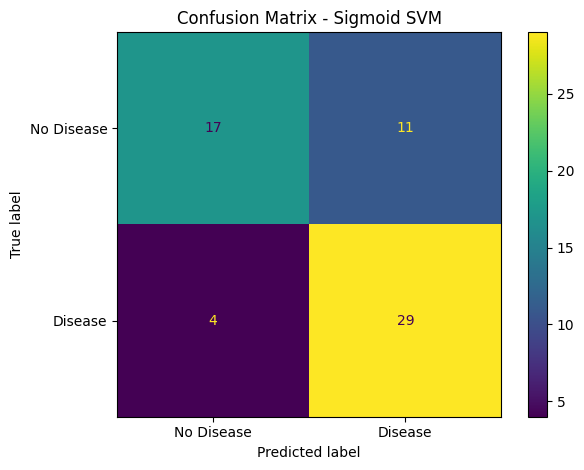

Best parameters : {'C': 1, 'gamma': 'scale'}
CV accuracy     : 0.8474489795918367
Train accuracy  : 0.8181818181818182
Test accuracy   : 0.7540983606557377
Precision       : 0.725
Recall          : 0.8787878787878788
Specificity     : 0.6071428571428571
F1-score        : 0.7945205479452054
ROC-AUC         : 0.8430735930735931
Overfit gap     : 0.06408345752608058

Confusion Matrix:
[[17 11]
 [ 4 29]]
TN = 17
FP = 11
FN = 4
TP = 29


FINAL MODEL COMPARISON
              Model  CV Accuracy  Train Accuracy  Test Accuracy  Precision  Recall  Specificity     F1  ROC-AUC  Overfit Gap
     Polynomial SVM       0.8266          0.9463         0.7705     0.7436  0.8788       0.6429 0.8056   0.9037       0.1758
         Linear SVM       0.8393          0.8595         0.7869     0.7500  0.9091       0.6429 0.8219   0.8842       0.0726
            RBF SVM       0.8598          0.8678         0.8033     0.7561  0.9394       0.6429 0.8378   0.8820       0.0645
Logistic Regression       0.8391        

In [161]:

# ==========================================================
# 1. Models + Hyperparameter grids
# ==========================================================

models = {

    'Logistic Regression': (
        LogisticRegression(max_iter=20000),
        {
            'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
        }
    ),

    'Linear SVM': (
        SVC(kernel='linear', probability=True),
        {
            'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
        }
    ),

    'Polynomial SVM': (
        SVC(kernel='poly', probability=True),
        {
            'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
            'degree': [2, 3, 4, 5],
            'gamma': ['scale', 'auto', 'scale', 0.0001, 0.001, 0.01, 0.1]
        }
    ),

    'RBF SVM': (
        SVC(kernel='rbf', probability=True),
        {
            'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
            'gamma': ['scale', 'auto', 'scale', 0.0001, 0.001, 0.01, 0.1]
        }
    ),

    'Sigmoid SVM': (
        SVC(kernel='sigmoid', probability=True),
        {
            'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
            'gamma': ['scale', 'auto', 'scale', 0.0001, 0.001, 0.01, 0.1]
        }
    )
}


# ==========================================================
# 2. GridSearch + Evaluation
# ==========================================================

results = []

for name, (model, param_grid) in models.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    # Grid Search
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train_scaled, y_train)

    best_model = grid.best_estimator_

    # ------------------------------------------------------
    # Predictions
    # ------------------------------------------------------

    train_pred = best_model.predict(X_train_scaled)
    test_pred = best_model.predict(X_test_scaled)

    # Probability for ROC-AUC
    test_prob = best_model.predict_proba(X_test_scaled)[:, 1]

    # ------------------------------------------------------
    # Confusion Matrix
    # ------------------------------------------------------

    cm = confusion_matrix(y_test, test_pred)

    tn, fp, fn, tp = cm.ravel()

    # ------------------------------------------------------
    # Plot Confusion Matrix
    # ------------------------------------------------------

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Disease', 'Disease']
    )

    disp.plot()

    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------
    # Metrics
    # ------------------------------------------------------

    accuracy = accuracy_score(y_test, test_pred)

    precision = precision_score(
        y_test,
        test_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        test_pred,
        zero_division=0
    )

    specificity = tn / (tn + fp)

    f1 = f1_score(
        y_test,
        test_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        test_prob
    )

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    overfit_gap = train_accuracy - accuracy

    # ------------------------------------------------------
    # Store results
    # ------------------------------------------------------

    results.append({
        'Model': name,
        'CV Accuracy': grid.best_score_,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'Overfit Gap': overfit_gap,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Best Parameters': str(grid.best_params_)
    })

    # ------------------------------------------------------
    # Print individual results
    # ------------------------------------------------------

    print("Best parameters :", grid.best_params_)
    print("CV accuracy     :", grid.best_score_)
    print("Train accuracy  :", train_accuracy)
    print("Test accuracy   :", accuracy)
    print("Precision       :", precision)
    print("Recall          :", recall)
    print("Specificity     :", specificity)
    print("F1-score        :", f1)
    print("ROC-AUC         :", roc_auc)
    print("Overfit gap     :", overfit_gap)

    print("\nConfusion Matrix:")
    print(cm)

    print(f"TN = {tn}")
    print(f"FP = {fp}")
    print(f"FN = {fn}")
    print(f"TP = {tp}")


# ==========================================================
# 3. Final comparison table
# ==========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='ROC-AUC',
    ascending=False
)


# ==========================================================
# 4. Main results table
# ==========================================================

print("\n\nFINAL MODEL COMPARISON")
print("=" * 150)

main_columns = [
    'Model',
    'CV Accuracy',
    'Train Accuracy',
    'Test Accuracy',
    'Precision',
    'Recall',
    'Specificity',
    'F1',
    'ROC-AUC',
    'Overfit Gap'
]

print(
    results_df[
        main_columns
    ].round(4).to_string(index=False)
)


# ==========================================================
# 5. Confusion Matrix values
# ==========================================================

print("\n\nCONFUSION MATRIX VALUES")
print("=" * 100)

cm_columns = [
    'Model',
    'TN',
    'FP',
    'FN',
    'TP'
]

print(
    results_df[
        cm_columns
    ].to_string(index=False)
)


# ==========================================================
# 6. Best Parameters
# ==========================================================

print("\n\nBEST PARAMETERS")
print("=" * 100)

for _, row in results_df.iterrows():
    print(f"{row['Model']}: {row['Best Parameters']}")